In [6]:
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


#### Load and Prepare Image


In [7]:
img = io.imread("lena.jpg")
img = np.array(img)

#### Convert RGB to grayscale using standard formula


In [8]:
def rgb2gray(rgb):
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray.astype(np.uint8)

gray_img = rgb2gray(img)

### Implement filter1() – basic convolution with offset (no edge handling yet)

If the filter is 3×3 → K = 1

If the filter is 5×5 → K = 2

If the filter is 7×7 → K = 3 <br><br>

#### out height and width: “How many steps can I take vertically from top to bottom, without hitting the border?”

You don’t apply the filter on the border of the image (because there's no padding)

K is how many pixels the filter extends above and below the center pixel

So you remove K pixels from the top and bottom → 2*K total

Example: for a 3×3 filter, K = 1 → you lose 1 pixel on each edge

#### loop:

 loop over every **valid center pixel** in the image.
- start at `K` (e.g. `1` for a 3×3 filter) so the filter doesn’t go out of bounds.
- go up to `height - K`, skipping pixels by `offset` (stride).
- Same for `x`: move horizontally in steps of `offset`.

>  This loop says:  
> “Slide the filter across the image, staying away from the edges, and move by `offset` pixels each step.”

In [48]:
def filter1(img, filt, offset):
    """
    Apply a linear filter with a given offset (stride) to a grayscale image.
    
    Parameters:
        img (2D np.array): input grayscale image
        filt (2D np.array): filter kernel (must be square NxN)
        offset (int): how many pixels to skip (stride)
        
    Returns:
        result (2D np.array): filtered output image
    """
    K = filt.shape[0] //2  #pixel from the center to the edge
    height, width = img.shape

    # output image size (depends on offset and border handling)
    out_height = (height - 2 * K) // offset
    out_width = (width - 2 * K) // offset
    result = np.zeros((out_height, out_width), dtype=np.uint8)

    # convolution
    for y in range(K, height - K, offset):
        for x in range(K, width - K, offset):
            # extract the local neighborhood
            region = img[y - K:y + K + 1, x - K:x + K + 1]
            # apply filter and clip the result to [0, 255]
            filtered_value = np.sum(region * filt)
            filtered_value = np.clip(filtered_value, 0, 255)
            result[(y - K) // offset, (x - K) // offset] = int(filtered_value)
    
    return result


#### Define filter masks

In [84]:
fm1 = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

fm2 = np.array([
    [1, 0, 1],
    [1, 0, 1],
    [1, 0, 1]
])

fm3 = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

fm4 = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

fm5 = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
])

#### Apply filter1() and Show Result

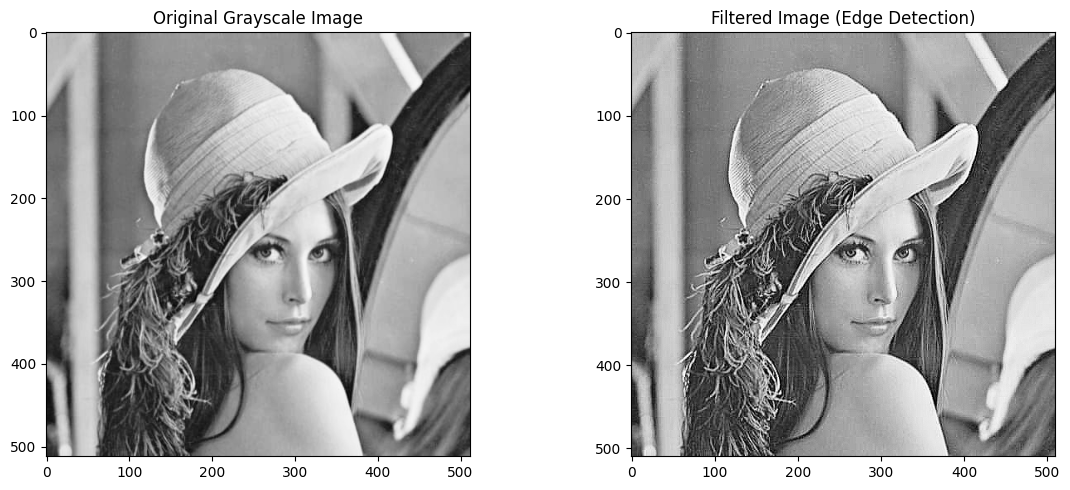

In [85]:
img1_out = filter1(gray_img, fm5, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Grayscale Image")
plt.imshow(gray_img, cmap=cm.Greys_r)

plt.subplot(1, 2, 2)
plt.title("Filtered Image (Edge Detection)")
plt.imshow(img1_out, cmap=cm.Greys_r)

plt.tight_layout()
plt.show()


### Second filter function:
#### first lets define the functions that conrol the padding type.

#### Padding method 1: Zero padding (min)
    Pads the image with zeros on all sides (zero padding).

In [74]:
def pad_min(img, k):
    return np.pad(img, pad_width=k, mode='constant', constant_values=0)

#### Padding method 2: Max value padding (255)
Pads the image with 255 on all sides.

In [75]:
def pad_max(img, k):
    return np.pad(img, pad_width=k, mode='constant', constant_values=255)

#### Padding method 3: Edge replication (continue)
Pads the image by repeating the edge values.

In [76]:
def pad_continue(img, k):
    return np.pad(img, pad_width=k, mode='edge')

#### filter2() now also handles edges based on the chosen padding type.

In [77]:
def filter2(img, filt, offset, edge):
    """
    Apply a linear filter with stride (offset) and edge handling.

    Parameters:
        img (2D np.array): input grayscale image
        filt (2D np.array): filter kernel (NxN, with N=2K+1)
        offset (int): stride (how many pixels to skip when sliding the filter)
        edge (str): padding method - 'min', 'max', or 'continue'

    Returns:
        result (2D np.array): filtered output image
    """
    K = filt.shape[0] // 2
    height, width = img.shape

    if edge == 'min':
        padded = pad_min(img, K)
    elif edge == 'max':
        padded = pad_max(img, K)
    elif edge == 'continue':
        padded = pad_continue(img, K)
    else:
        raise ValueError("Unknown edge type. Use 'min', 'max', or 'continue'.")

    # prepare output image
    out_height = (height - 0) // offset
    out_width = (width - 0) // offset
    result = np.zeros((out_height, out_width), dtype=np.uint8)

    # convolution
    for y in range(0, out_height * offset, offset):
        for x in range(0, out_width * offset, offset):
            # get region from padded image
            region = padded[y:y + 2 * K + 1, x:x + 2 * K + 1]
            # Apply filter
            filtered_value = np.sum(region * filt)
            # clip
            filtered_value = np.clip(filtered_value, 0, 255)
            # write to output
            result[y // offset, x // offset] = int(filtered_value)

    return result

#### show the filtered iage with filter2() that handles edges

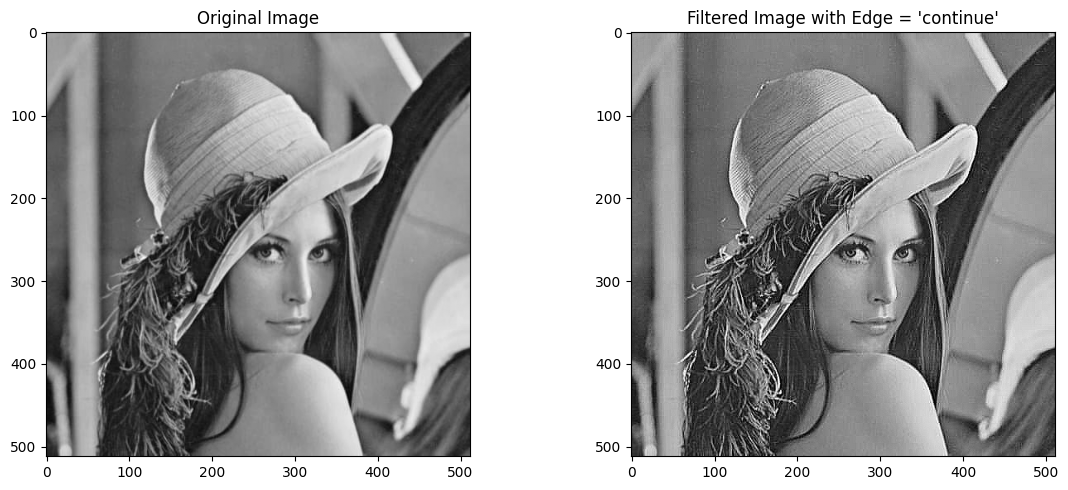

In [86]:
img2_out = filter2(gray_img, fm5, 1, 'continue')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(gray_img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Filtered Image with Edge = 'continue'")
plt.imshow(img2_out, cmap='gray')

plt.tight_layout()
plt.show()

#### compare output of filter1 with output of filter2

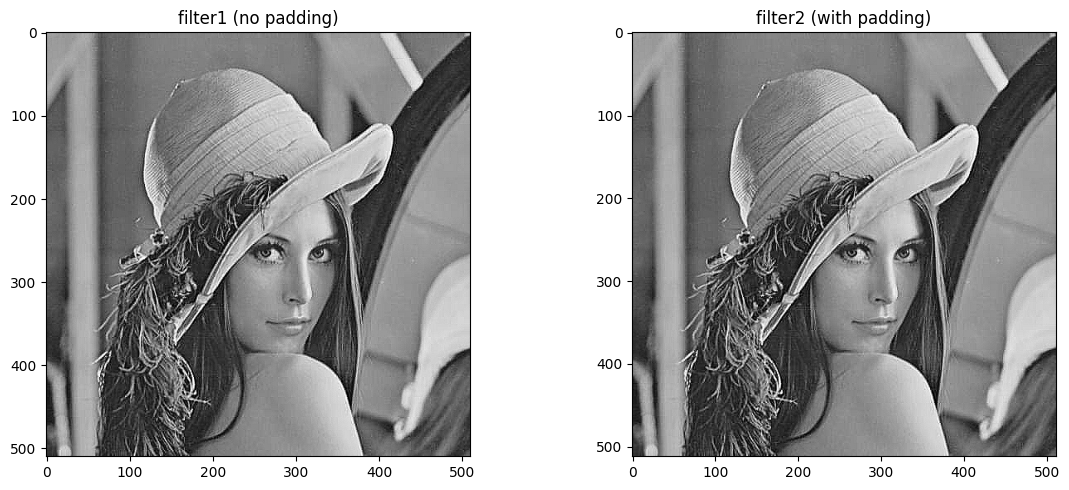

In [87]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1_out, cmap='gray')
plt.title("filter1 (no padding)")

plt.subplot(1, 2, 2)
plt.imshow(img2_out, cmap='gray')
plt.title("filter2 (with padding)")

plt.tight_layout()
plt.show()
